In this script we will cluster the data, look for differential expression of cells and annotate the clusters.

We will limit our analysis to the global dataset and the sorted subset of data as the clustering of the time points doesn't seem very relevant.


In [1]:
import scanpy as scp
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns
import numpy as np
import pandas as pd
import io
import os

from parameters import *

import warnings
warnings.filterwarnings("ignore") 

# Global <a name="whole"></a>

In [2]:
adata = scp.read("results/QC.h5ad")

## Clustering <a name="whole_clustering"></a>

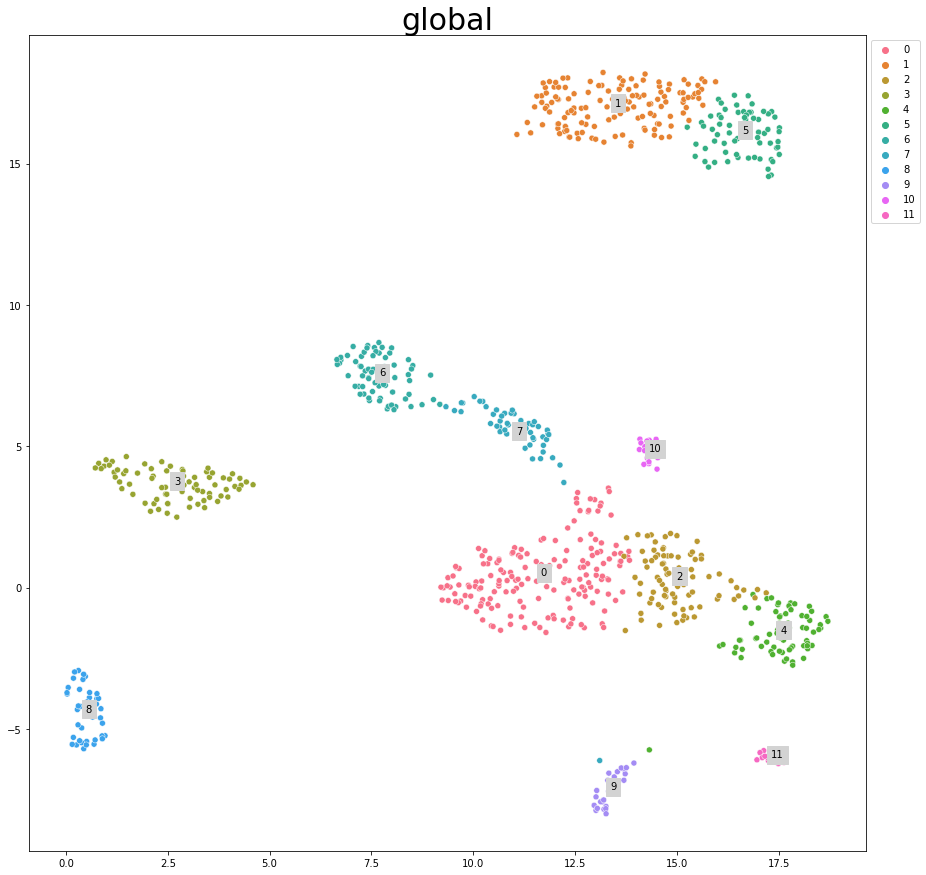

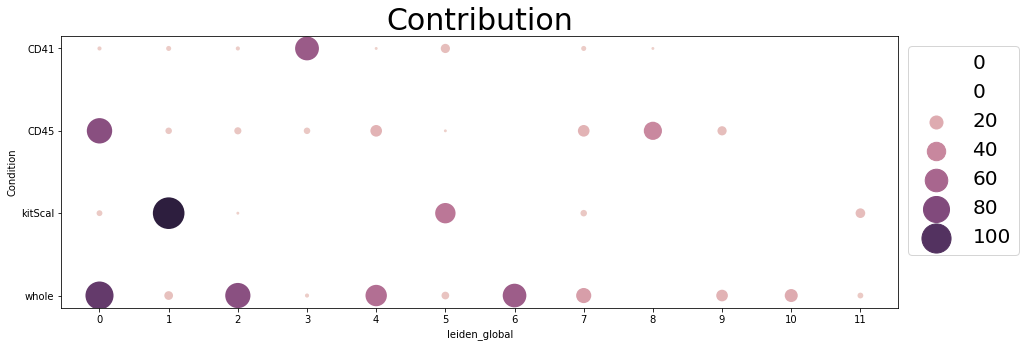

In [3]:
fig,ax = plt.subplots(1,1,figsize=[15,15])
fig2,ax2 = plt.subplots(1,1,figsize=[15,5])

pca = "X_pca"
umap = "X_umap"

#Clustering global
scp.tl.leiden(adata,resolution=RESOLUTION, key_added="leiden_global")
    
    #Scatter plots
sns.scatterplot(x=adata.obsm[umap][:,0],y=adata.obsm[umap][:,1],hue=adata.obs["leiden_global"],ax=ax)
ax.set_title("global",fontsize=30)   
ax.legend(bbox_to_anchor=(1,1), loc="upper left")
for cluster in adata.obs["leiden_global"].unique():
    x = adata[adata.obs["leiden_global"]==cluster,:].obsm[umap][:,0].mean()
    y = adata[adata.obs["leiden_global"]==cluster,:].obsm[umap][:,1].mean()
    ax.text(x,y,cluster,backgroundcolor="lightgrey")
    
    #Make cluster contributions
data = adata.obs.groupby(by=["leiden_global","Condition"]).count()
data2 = data.unstack().loc[:,"Cell"].stack().reset_index()
sns.scatterplot(data=data2,x="leiden_global",y="Condition",hue=0,size=0,sizes=(0, 1000),ax=ax2)
ax2.set_title("Contribution",fontsize=30)   
ax2.legend(bbox_to_anchor=(1,1), loc="upper left",fontsize=20)

#Save clusters
adata.write("results/QC.h5ad")
    
#Save figures
fig.savefig("plots/global/scatterplot_clusters.png",bbox_inches="tight")
fig2.savefig("plots/global/condition_contribution_clusters.png",bbox_inches="tight")

## DE expression <a name="whole_DE_genes"></a>

We use Wilconxon rank test for the discovery of differentially expressed genes comnparing each cluster against the rest. The information saved in the tables folder.

In [4]:
if not os.path.isdir("tables"):
    os.mkdir("tables")
    
if not os.path.isdir("tables/global"):
    os.mkdir("tables/global")
    
scp.tl.rank_genes_groups(adata,groupby="leiden_global",method="wilcoxon",use_raw=False)
n_genes = 200
        
writer = pd.ExcelWriter("tables/global/DE_global.xlsx", engine='xlsxwriter')
for k,group in enumerate(adata.uns["rank_genes_groups"]["names"].dtype.names):
            
    l = pd.DataFrame(columns=["names","logfoldchanges","pvals","pvals_adj","scores"])
    l.loc[:,"names"] = adata.var.loc[[n[k] for n in adata.uns["rank_genes_groups"]["names"]][:n_genes],"gene_name"].values
    l.loc[:,"logfoldchanges"] = [n[k] for n in adata.uns["rank_genes_groups"]["logfoldchanges"]][:n_genes]
    l.loc[:,"pvals"] = [n[k] for n in adata.uns["rank_genes_groups"]["pvals"]][:n_genes]
    l.loc[:,"pvals_adj"] = [n[k] for n in adata.uns["rank_genes_groups"]["pvals_adj"]][:n_genes]
    l.loc[:,"scores"] = [n[k] for n in adata.uns["rank_genes_groups"]["scores"]][:n_genes]
    
    l.to_excel(writer, sheet_name="cluster_"+str(k))
        
writer.save()

##  Relevant genes expression <a name="whole_relevant"></a>

In [5]:
genes = pd.read_excel("Marker_genes_scRNAseq_Gx.xlsx",header=None).values[:,0]

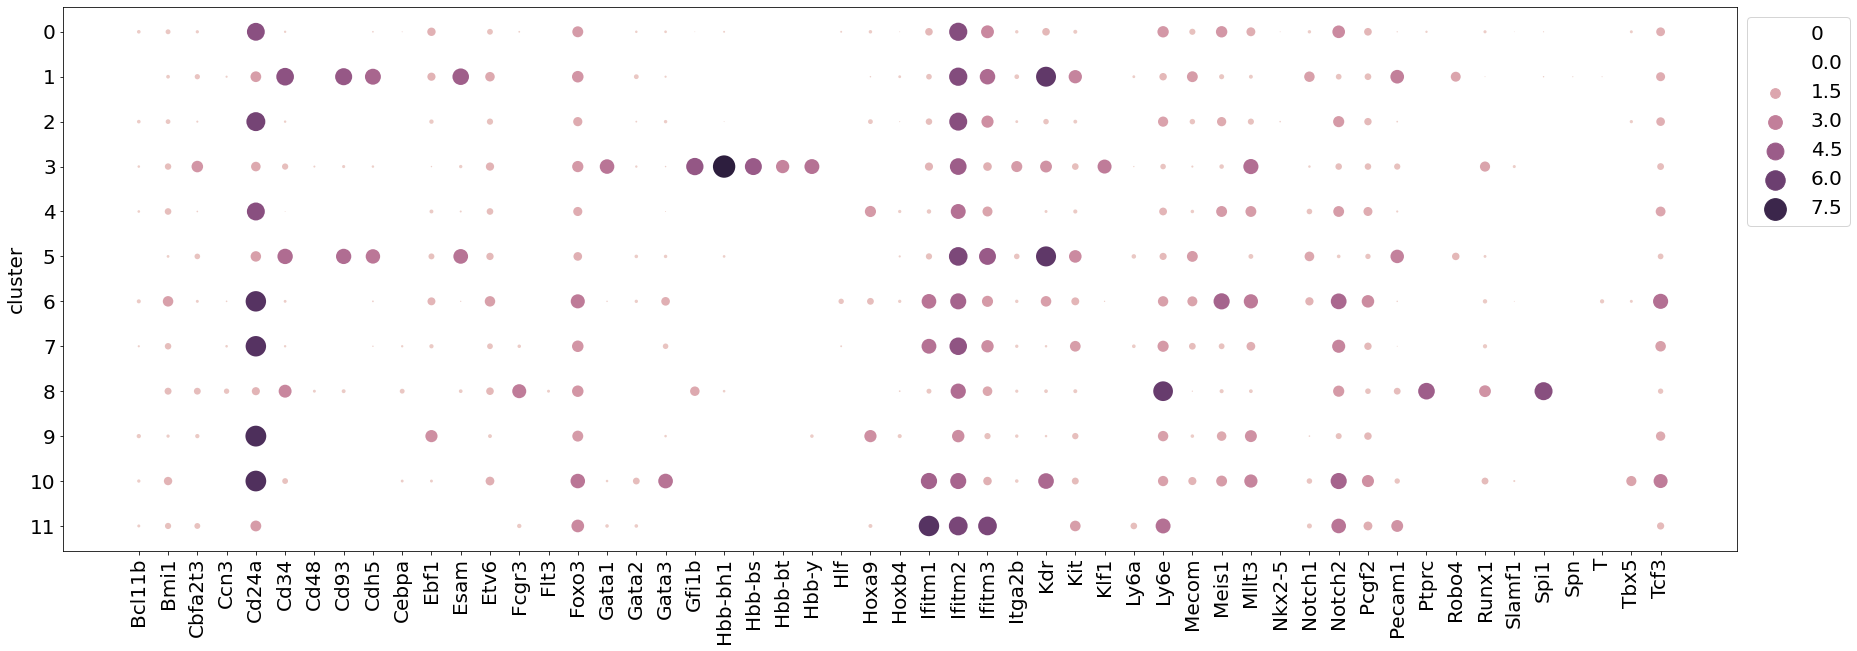

In [6]:
fig,ax = plt.subplots(1,1,figsize=[30,10])

data = pd.DataFrame()
data["cluster"] = adata.obs["leiden_global"]
for gene in np.sort(genes):
    if np.array(adata[:,adata.var.loc[:,"gene_name"]==gene].X.todense()).size != 0:
        data[gene] = np.array(adata[:,adata.var.loc[:,"gene_name"]==gene].X.todense())[:,0]
        
data = data.groupby(["cluster"]).mean().stack().reset_index()

sns.scatterplot(data=data,y="cluster",x="level_1",hue=0,size=0,sizes=(0,500),ax=ax)
ax.legend(bbox_to_anchor=(1,1), loc="upper left",fontsize=20)
ax.set_ylabel("cluster",fontsize=20)
ax.set_xlabel("")
for tick in ax.get_xticklabels():
    tick.set_rotation(90)
    tick.set_fontsize(20)
for tick in ax.get_yticklabels():
    tick.set_fontsize(20)
    
fig.savefig("plots/global/expression_relevant_genes_clusters.png")

# Sorted <a name="sorted"></a>

In [7]:
adata = scp.read("results/subSamples/sorted/sorted.h5ad")

## Clustering <a name="sorted_clustering"></a>

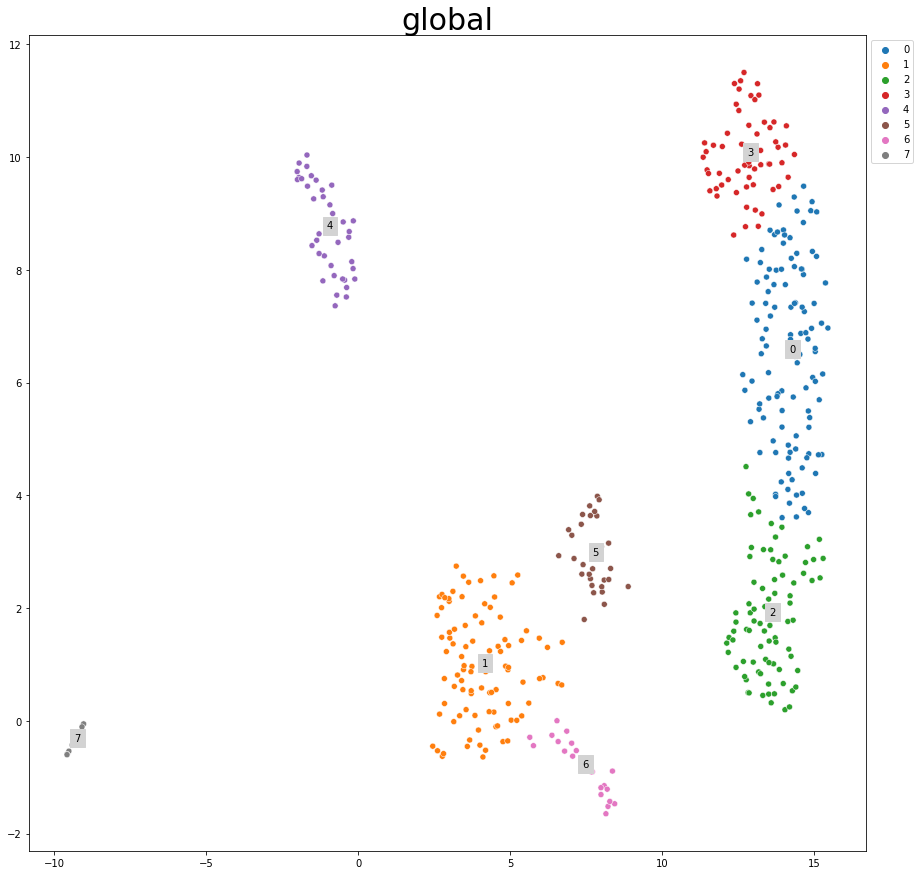

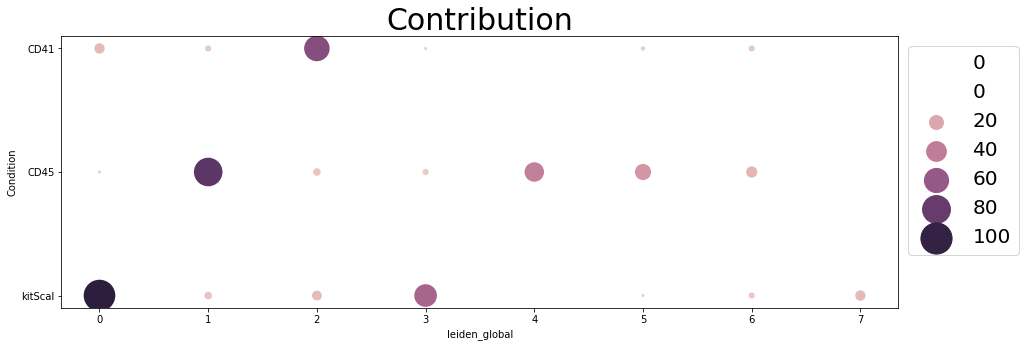

In [8]:
fig,ax = plt.subplots(1,1,figsize=[15,15])
fig2,ax2 = plt.subplots(1,1,figsize=[15,5])

pca = "X_pca"
umap = "X_umap"

#Clustering global
scp.tl.leiden(adata,resolution=RESOLUTION, key_added="leiden_global")
    
    #Scatter plots
sns.scatterplot(x=adata.obsm[umap][:,0],y=adata.obsm[umap][:,1],hue=adata.obs["leiden_global"],ax=ax)
ax.set_title("global",fontsize=30)   
ax.legend(bbox_to_anchor=(1,1), loc="upper left")
for cluster in adata.obs["leiden_global"].unique():
    x = adata[adata.obs["leiden_global"]==cluster,:].obsm[umap][:,0].mean()
    y = adata[adata.obs["leiden_global"]==cluster,:].obsm[umap][:,1].mean()
    ax.text(x,y,cluster,backgroundcolor="lightgrey")
    
    #Make cluster contributions
data = adata.obs.groupby(by=["leiden_global","Condition"]).count()
data2 = data.unstack().loc[:,"Cell"].stack().reset_index()
sns.scatterplot(data=data2,x="leiden_global",y="Condition",hue=0,size=0,sizes=(0, 1000),ax=ax2)
ax2.set_title("Contribution",fontsize=30)   
ax2.legend(bbox_to_anchor=(1,1), loc="upper left",fontsize=20)

#Save clusters
adata.write("results/subSamples/sorted/sorted.h5ad")
    
#Save figures
fig.savefig("plots/sorted/scatterplot_clusters.png",bbox_inches="tight")
fig2.savefig("plots/sorted/condition_contribution_clusters.png",bbox_inches="tight")

## DE expression <a name="sorted_DE_genes"></a>

We use Wilconxon rank test for the discovery of differentially expressed genes comnparing each cluster against the rest.

In [9]:
if not os.path.isdir("tables/sorted"):
    os.mkdir("tables/sorted")
    
scp.tl.rank_genes_groups(adata,groupby="leiden_global",method="wilcoxon",use_raw=False)
n_genes = 200
        
writer = pd.ExcelWriter("tables/sorted/DE_sorted.xlsx", engine='xlsxwriter')
for k,group in enumerate(adata.uns["rank_genes_groups"]["names"].dtype.names):
            
    l = pd.DataFrame(columns=["names","logfoldchanges","pvals","pvals_adj","scores"])
    l.loc[:,"names"] = adata.var.loc[[n[k] for n in adata.uns["rank_genes_groups"]["names"]][:n_genes],"gene_name"].values
    l.loc[:,"logfoldchanges"] = [n[k] for n in adata.uns["rank_genes_groups"]["logfoldchanges"]][:n_genes]
    l.loc[:,"pvals"] = [n[k] for n in adata.uns["rank_genes_groups"]["pvals"]][:n_genes]
    l.loc[:,"pvals_adj"] = [n[k] for n in adata.uns["rank_genes_groups"]["pvals_adj"]][:n_genes]
    l.loc[:,"scores"] = [n[k] for n in adata.uns["rank_genes_groups"]["scores"]][:n_genes]
    
    l.to_excel(writer, sheet_name="cluster_"+str(k))
        
writer.save()

##  Relevant genes expression <a name="sorted_relevant"></a>

In [10]:
genes = pd.read_excel("Marker_genes_scRNAseq_Gx.xlsx",header=None).values[:,0]

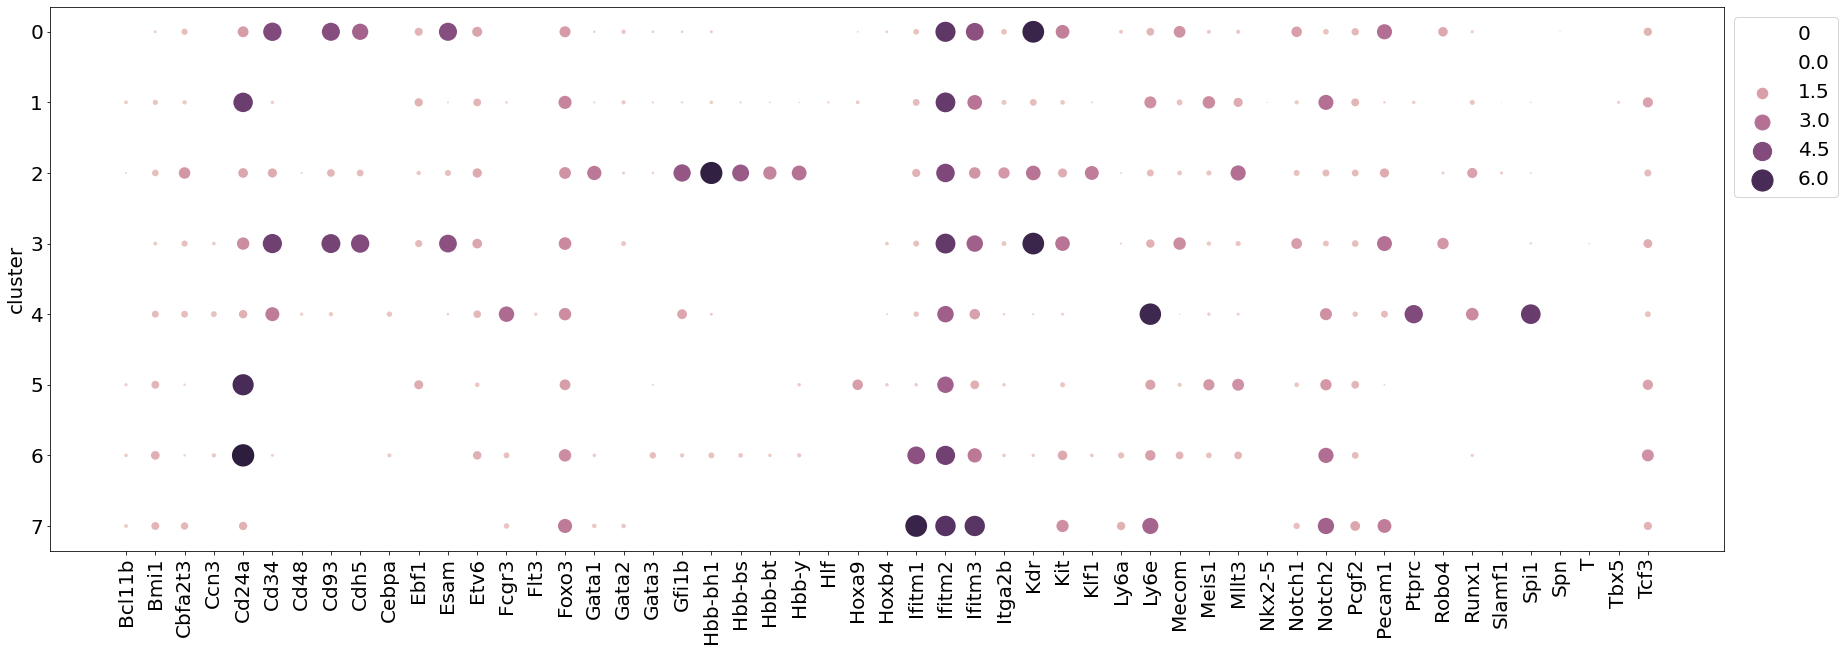

In [11]:
fig,ax = plt.subplots(1,1,figsize=[30,10])

data = pd.DataFrame()
data["cluster"] = adata.obs["leiden_global"]
for gene in np.sort(genes):
    if np.array(adata[:,adata.var.loc[:,"gene_name"]==gene].X.todense()).size != 0:
        data[gene] = np.array(adata[:,adata.var.loc[:,"gene_name"]==gene].X.todense())[:,0]
        
data = data.groupby(["cluster"]).mean().stack().reset_index()

sns.scatterplot(data=data,y="cluster",x="level_1",hue=0,size=0,sizes=(0,500),ax=ax)
ax.legend(bbox_to_anchor=(1,1), loc="upper left",fontsize=20)
ax.set_ylabel("cluster",fontsize=20)
ax.set_xlabel("")
for tick in ax.get_xticklabels():
    tick.set_rotation(90)
    tick.set_fontsize(20)
for tick in ax.get_yticklabels():
    tick.set_fontsize(20)
    
fig.savefig("plots/sorted/expression_relevant_genes_clusters.png")